In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

In [2]:
df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")
print(df.head())

         date  year  month  day         region    country category  \
0  2025-10-12  2025     10   12    Middle East        UAE  Chronic   
1  2020-09-15  2020      9   15     South Asia      India  Chronic   
2  2020-02-26  2020      2   26    Middle East        UAE  Vitamin   
3  2025-11-09  2025     11    9     South Asia  Sri Lanka  Chronic   
4  2022-04-04  2022      4    4  South America  Argentina  Chronic   

     medicine age_group  units_sold  unit_price  stock_level  \
0  Amlodipine      0-12         328       45.38         4774   
1  Amlodipine     26-45         371       75.49         4584   
2   Vitamin C      0-12         948       22.51         3934   
3  Amlodipine      0-12         275       63.29         4544   
4  Amlodipine     26-45         563       44.28         4284   

   expiry_days_remaining  covid_flag  
0                    466           0  
1                    181           1  
2                    556           1  
3                    330           0  

In [6]:
# convert date col in to dattime format 
df["date"] = pd.to_datetime(df["date"])
# data short by dates
df = df.sort_values("date")

date
2020-01-01    65568
2020-01-02    71525
2020-01-03    53610
2020-01-04    55388
2020-01-05    58204
              ...  
2025-12-27    33217
2025-12-28    27652
2025-12-29    34287
2025-12-30    27584
2025-12-31    28828
Name: units_sold, Length: 2192, dtype: int64


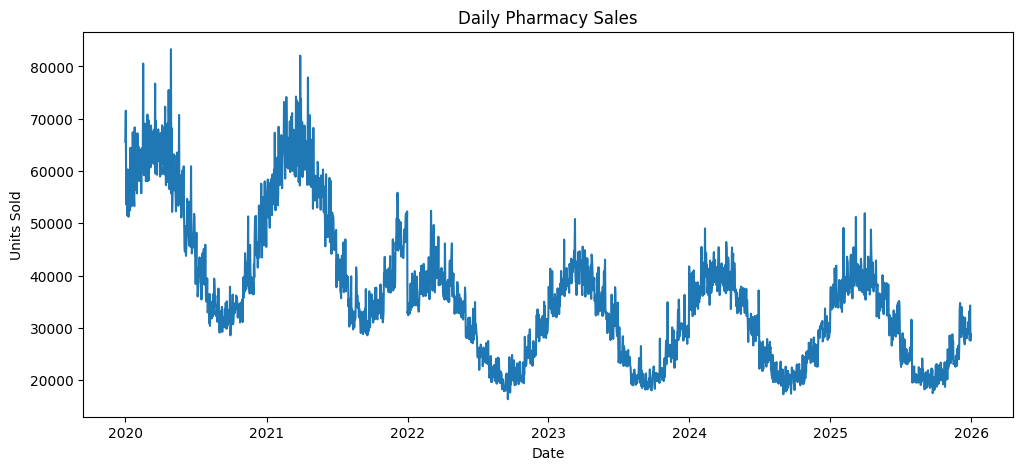

In [9]:
# create the daily salse data for trend analysis
daily_sales = df.groupby("date")["units_sold"].sum()
print(daily_sales)
plt.figure(figsize=(12,5))

plt.plot(daily_sales)
plt.title("daily Pharmacy Sales")
plt.xlabel("Date")
plt.ylabel("units sold")

plt.show()

year
2020    17780074
2021    17705185
2022    11006721
2023    11081907
2024    11094960
2025    11055339
Name: units_sold, dtype: int64


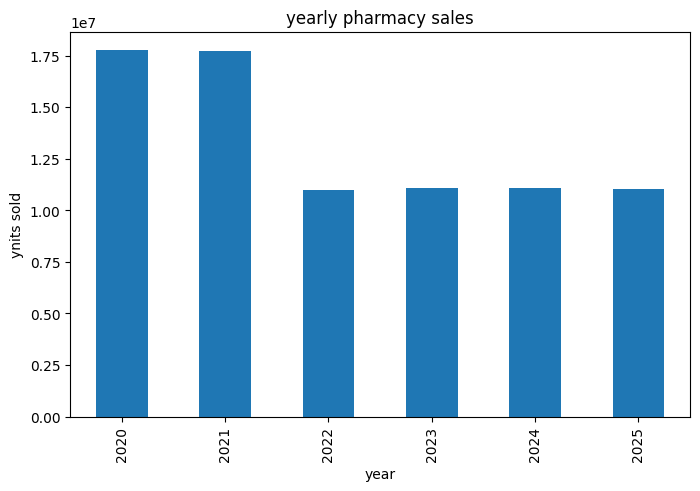

In [13]:
#Yearly trend analysis 
yearly_sales = df.groupby("year")["units_sold"].sum()
print(yearly_sales)
yearly_sales.plot(kind="bar", figsize=(8,5))
plt.title("yearly pharmacy sales")
plt.xlabel("year")
plt.ylabel("ynits sold")

plt.show()

date
1     7970454
2     8056917
3     9129266
4     8616463
5     7897499
6     6612286
7     5586378
8     4702189
9     4276707
10    4713159
11    5411660
12    6751208
Name: units_sold, dtype: int64


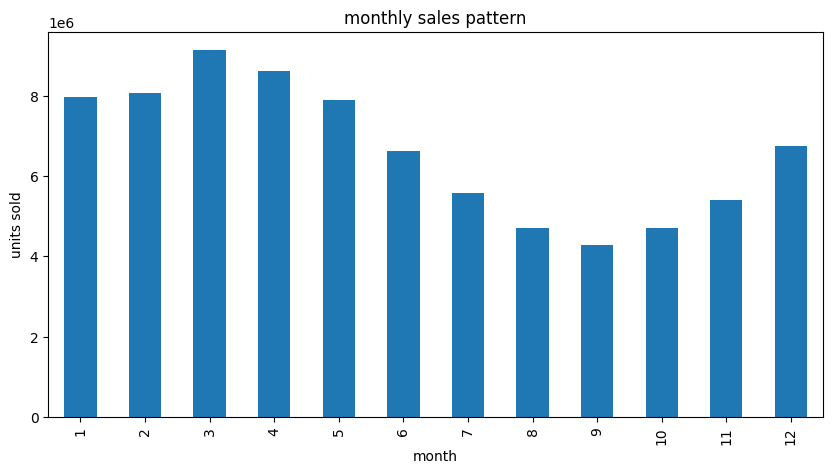

In [16]:
# monthly Seasonality
monthly_sales = df.groupby(df["date"].dt.month)["units_sold"].sum()
print(monthly_sales)
monthly_sales.plot(kind="bar", figsize=(10,5))
plt.title("monthly sales pattern")
plt.xlabel("month")
plt.ylabel("units sold")
plt.show()

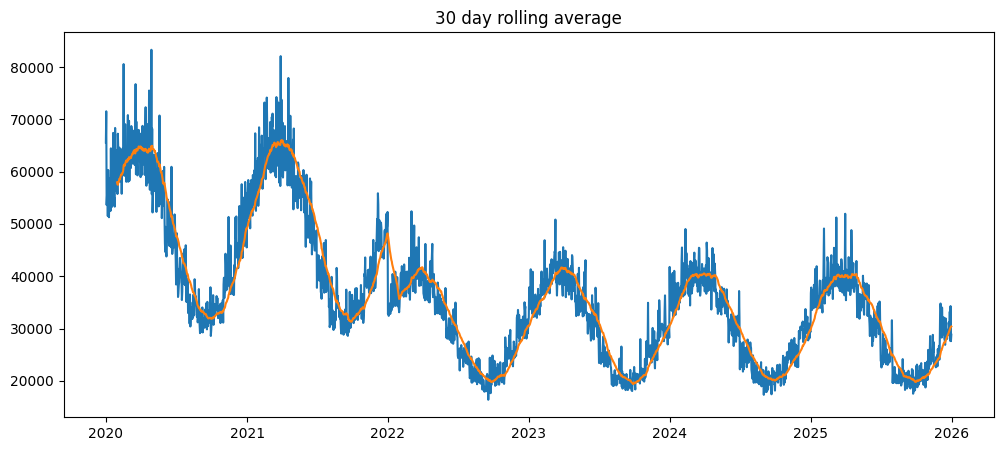

In [18]:
# analyze the 30 day rolling average 
rol30 = daily_sales.rolling(30).mean()
plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.plot(rol30)
plt.title("30 day rolling average")
plt.show()

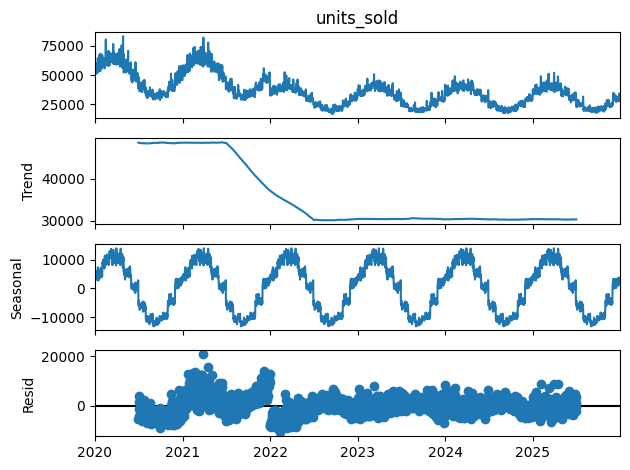

In [25]:
# our data is in daily format days contain so we use formula for yearly seasonality in decomposition
result = seasonal_decompose(
    daily_sales,
    model="additive",
    period=365
)
result.plot()
plt.show()

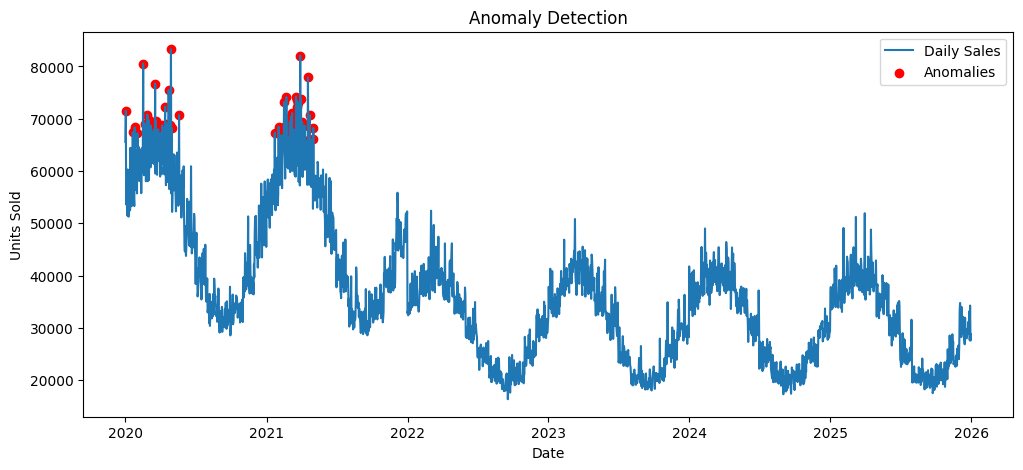

In [30]:
# detect anomalies using iqr range techniques upper and lower limits 
Q1 = daily_sales.quantile(0.25)
Q3 = daily_sales.quantile(0.75)
IQR = Q3 - Q1

# setting up the limit ranges 
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
anomalies = daily_sales[
    (daily_sales < lower_limit) |
    (daily_sales > upper_limit)
]

plt.figure(figsize=(12, 5))

plt.plot(daily_sales, label="Daily Sales")

plt.scatter(
    anomalies.index,
    anomalies.values,
    color="red",
    label="Anomalies"
)

plt.title("Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()
plt.show()

covid_flag
0    372.924604
1    597.767279
Name: units_sold, dtype: float64


<Axes: xlabel='covid_flag'>

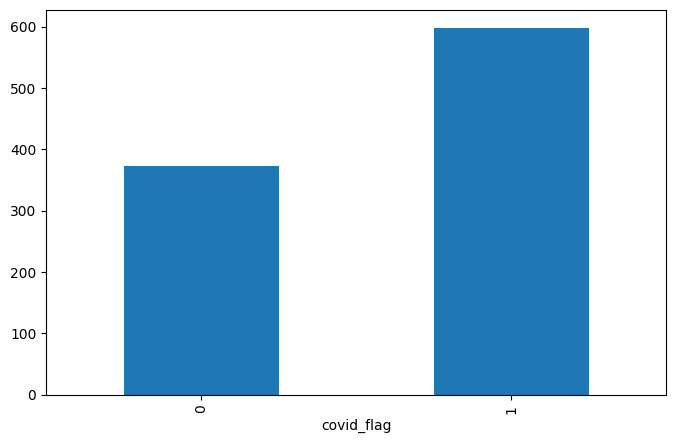

In [35]:
# compair salse during covid 
covid_sales = df.groupby(
    "covid_flag"
)["units_sold"].mean()

print(covid_sales)
covid_sales.plot(kind="bar", figsize=(8,5))
